In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model, Sequential
import numpy as np
import pandas as pd
import shutil
import time
import cv2 as cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import os
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report


In [5]:
sdir=r'../input/plantdisease/PlantVillage'
classlist=os.listdir(sdir)    
filepaths=[]
labels=[]    
for klass in classlist:
    classpath=os.path.join(sdir,klass)
    if os.path.isdir(classpath):
        flist=os.listdir(classpath)        
        for f in flist:
            fpath=os.path.join(classpath,f)        
            filepaths.append(fpath)
            labels.append(klass)
Fseries=pd.Series(filepaths, name='filepaths')
Lseries=pd.Series(labels, name='labels')    
df=pd.concat([Fseries, Lseries], axis=1)    
print (df.head())
print('df length: ', len(df))
print (df['labels'].value_counts())

                                           filepaths  \
0  ../input/plantdisease/PlantVillage/Pepper__bel...   
1  ../input/plantdisease/PlantVillage/Pepper__bel...   
2  ../input/plantdisease/PlantVillage/Pepper__bel...   
3  ../input/plantdisease/PlantVillage/Pepper__bel...   
4  ../input/plantdisease/PlantVillage/Pepper__bel...   

                          labels  
0  Pepper__bell___Bacterial_spot  
1  Pepper__bell___Bacterial_spot  
2  Pepper__bell___Bacterial_spot  
3  Pepper__bell___Bacterial_spot  
4  Pepper__bell___Bacterial_spot  
df length:  20639
Tomato__Tomato_YellowLeaf__Curl_Virus          3209
Tomato_Bacterial_spot                          2127
Tomato_Late_blight                             1909
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato_healthy                                 1591
Pepper__bell___healthy                         1478
Tomato__Target_Spot                            1404
Potato___Early_blig

### this is a very unbalanced data set for df,  limit  maximum number of samples in a class to 500

In [6]:
sample_list=[]
max_size= 500
groups=df.groupby('labels')
for label in df['labels'].unique():                 
    group=groups.get_group(label)
    sample_count=len(group)    
    if sample_count> max_size:
        samples=group.sample(max_size, replace=False, weights=None, random_state=123, axis=0).reset_index(drop=True)
    else:
        samples=group.sample(frac=1.0, replace=False, random_state=123, axis=0).reset_index(drop=True)
    sample_list.append(samples)
df=pd.concat(sample_list, axis=0).reset_index(drop=True)
print (len(df))     
print (df['labels'].value_counts())     
        

7025
Tomato_healthy                                 500
Tomato__Tomato_YellowLeaf__Curl_Virus          500
Tomato_Spider_mites_Two_spotted_spider_mite    500
Tomato_Bacterial_spot                          500
Tomato_Septoria_leaf_spot                      500
Tomato_Leaf_Mold                               500
Tomato__Target_Spot                            500
Potato___Early_blight                          500
Pepper__bell___healthy                         500
Tomato_Late_blight                             500
Pepper__bell___Bacterial_spot                  500
Potato___Late_blight                           500
Tomato_Early_blight                            500
Tomato__Tomato_mosaic_virus                    373
Potato___healthy                               152
Name: labels, dtype: int64


In [7]:
working_dir=r'./'
aug_dir=os.path.join(working_dir, 'aug')
if os.path.isdir(aug_dir):
    shutil.rmtree(aug_dir)
os.mkdir(aug_dir)
for label in df['labels'].unique():
    dir_path=os.path.join(aug_dir,label)    
    os.mkdir(dir_path)
print(os.listdir(aug_dir))

['Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Late_blight', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato__Tomato_mosaic_virus', 'Potato___Early_blight', 'Pepper__bell___healthy', 'Tomato_healthy', 'Tomato__Target_Spot', 'Potato___Late_blight']


### create augmented images and store in the aug directories


In [8]:
target=500 # set the target count for each class in df
gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,
                              height_shift_range=.2, zoom_range=.2)
groups=df.groupby('labels') # group by class
for label in df['labels'].unique():  # for every class               
    group=groups.get_group(label)  # a dataframe holding only rows with the specified label 
    sample_count=len(group)   # determine how many samples there are in this class  
    if sample_count< target: # if the class has less than target number of images
        aug_img_count=0
        delta=target-sample_count  # number of augmented images to create
        target_dir=os.path.join(aug_dir, label)  # define where to write the images    
        aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=(224,224), class_mode=None,
                                        batch_size=1, shuffle=False, save_to_dir=target_dir, save_prefix='aug-',
                                        save_format='jpg')
        while aug_img_count<delta:
            images=next(aug_gen)            
            aug_img_count += len(images) 

Found 152 validated image filenames.
Found 373 validated image filenames.


In [9]:
aug=r'./aug'
auglist=os.listdir(aug)
for klass in auglist:
    classpath=os.path.join(aug, klass)
    flist=os.listdir(classpath)
    print('klass: ', klass, '  file count: ', len(flist))

klass:  Tomato_Leaf_Mold   file count:  0
klass:  Tomato_Septoria_leaf_spot   file count:  0
klass:  Tomato_Spider_mites_Two_spotted_spider_mite   file count:  0
klass:  Tomato_Early_blight   file count:  0
klass:  Tomato__Tomato_YellowLeaf__Curl_Virus   file count:  0
klass:  Tomato_Late_blight   file count:  0
klass:  Tomato_Bacterial_spot   file count:  0
klass:  Pepper__bell___Bacterial_spot   file count:  0
klass:  Potato___healthy   file count:  348
klass:  Tomato__Tomato_mosaic_virus   file count:  127
klass:  Potato___Early_blight   file count:  0
klass:  Pepper__bell___healthy   file count:  0
klass:  Tomato_healthy   file count:  0
klass:  Tomato__Target_Spot   file count:  0
klass:  Potato___Late_blight   file count:  0


### look at some augmented images

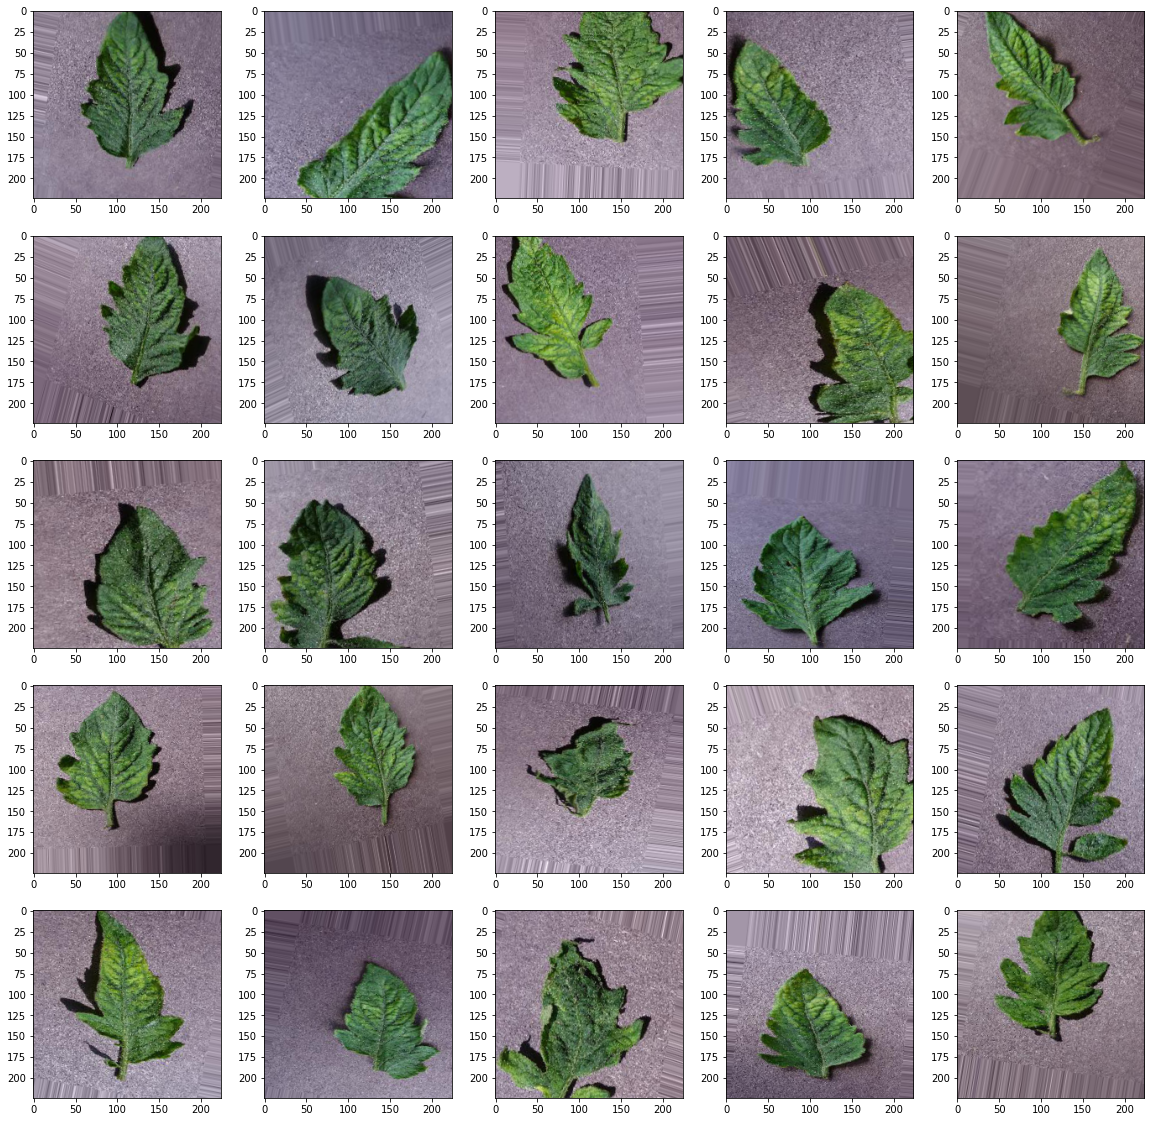

In [10]:
plt.figure(figsize=(20, 20))
for i in range(25):
    image=next(aug_gen)/255
    image=np.squeeze(image, axis=0)
    plt.subplot(5,5,i+1)
    plt.imshow(image)
plt.show()
            

In [11]:
aug_fpaths=[]
aug_labels=[]
classlist=os.listdir(aug_dir)
for klass in classlist:
    classpath=os.path.join(aug_dir, klass)     
    flist=os.listdir(classpath)    
    for f in flist:        
        fpath=os.path.join(classpath,f)         
        aug_fpaths.append(fpath)
        aug_labels.append(klass)
Fseries=pd.Series(aug_fpaths, name='filepaths')
Lseries=pd.Series(aug_labels, name='labels')
aug_df=pd.concat([Fseries, Lseries], axis=1)
ndf=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
#ndf=df.sample(frac=1.0, replace=False, random_state=123, axis=0).reset_index(drop=True)


print (df['labels'].value_counts()) 
print(aug_df['labels'].value_counts())
print (ndf['labels'].value_counts()) 

Tomato_healthy                                 500
Tomato__Tomato_YellowLeaf__Curl_Virus          500
Tomato_Spider_mites_Two_spotted_spider_mite    500
Tomato_Bacterial_spot                          500
Tomato_Septoria_leaf_spot                      500
Tomato_Leaf_Mold                               500
Tomato__Target_Spot                            500
Potato___Early_blight                          500
Pepper__bell___healthy                         500
Tomato_Late_blight                             500
Pepper__bell___Bacterial_spot                  500
Potato___Late_blight                           500
Tomato_Early_blight                            500
Tomato__Tomato_mosaic_virus                    373
Potato___healthy                               152
Name: labels, dtype: int64
Potato___healthy               348
Tomato__Tomato_mosaic_virus    152
Name: labels, dtype: int64
Tomato__Tomato_mosaic_virus                    525
Tomato_healthy                                 500
Tomato__T

###  now all classes in df have the target number of samples
### split df into train_df and valid_df

In [12]:
train_split=.8
valid_split=.1
dummy_split=valid_split/(1-train_split)
train_df, dummy_df=train_test_split(ndf, train_size=train_split, shuffle=True, random_state=123)
valid_df, test_df=train_test_split(dummy_df, train_size=dummy_split, shuffle=True, random_state=123)
print ('train_df length: ', len(train_df),'  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))

train_df length:  6020   test_df length:  753   valid_df length:  752


### create train, test, valid  generators

In [13]:
height=224
width=224
channels=3
batch_size=40
img_shape=(height, width, channels)
img_size=(height, width)
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]  
test_steps=int(length/test_batch_size)
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps)
def scalar(img):
    #img=img/127.5-1
    return img 
trgen=ImageDataGenerator(preprocessing_function=scalar, horizontal_flip=True)
tvgen=ImageDataGenerator(preprocessing_function=scalar)
sdir=r'../input/mars-surface-and-curiosity-image-set-nasa/Mars Surface and Curiosity Image/images'
train_gen=trgen.flow_from_dataframe( train_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=True, batch_size=batch_size)
test_gen=tvgen.flow_from_dataframe( test_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=False, batch_size=test_batch_size)
valid_gen=tvgen.flow_from_dataframe( valid_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=True, batch_size=batch_size)
classes=list(train_gen.class_indices.keys())
class_count=len(classes)
train_steps=int(len(train_gen.labels)/batch_size)



test batch size:  3   test steps:  251
Found 6020 validated image filenames belonging to 15 classes.
Found 753 validated image filenames belonging to 15 classes.
Found 752 validated image filenames belonging to 15 classes.


In [14]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())    
    images,labels=next(gen) # get a sample batch from the generator 
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=images[i]/255
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=10)
        plt.axis('off')
    plt.show()

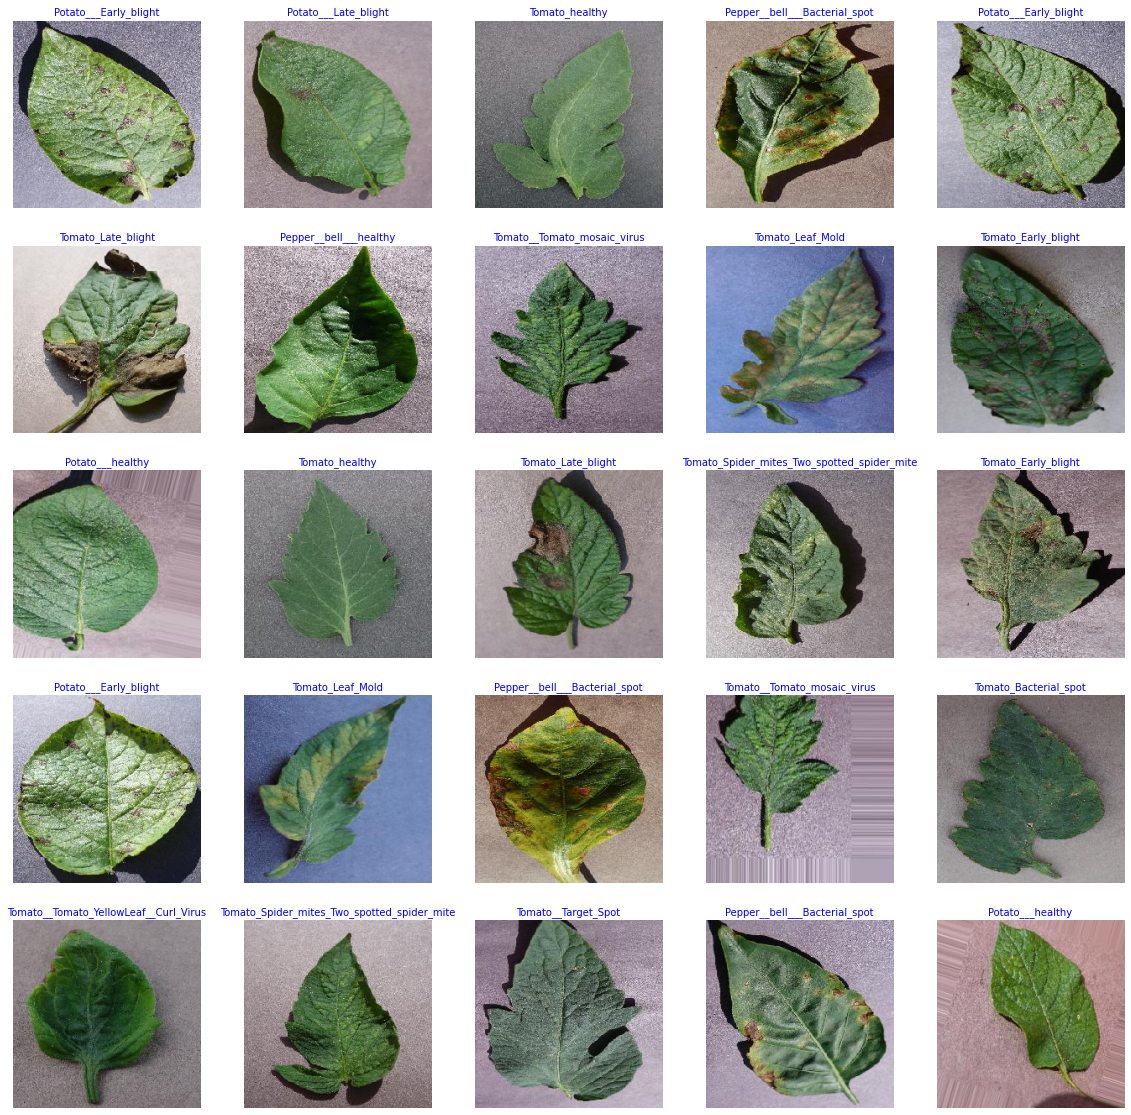

In [15]:
show_image_samples(train_gen)

In [16]:
def print_in_color(txt_msg,fore_tupple,back_tupple,):
    rf,gf,bf=fore_tupple
    rb,gb,bb=back_tupple
    msg='{0}' + txt_msg
    mat='\33[38;2;' + str(rf) +';' + str(gf) + ';' + str(bf) + ';48;2;' + str(rb) + ';' +str(gb) + ';' + str(bb) +'m' 
    print(msg .format(mat), flush=True)
    print('\33[0m', flush=True) # returns default print color to back to black
    return

In [17]:
model_name='EfficientNetB1'
base_model=tf.keras.applications.EfficientNetB1(include_top=False, weights="imagenet",input_shape=img_shape, pooling='max') 
x=base_model.output
x=keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
                bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
x=Dropout(rate=.45, seed=123)(x)        
output=Dense(class_count, activation='softmax')(x)
model=Model(inputs=base_model.input, outputs=output)
model.compile(Adamax(lr=.001), loss='categorical_crossentropy', metrics=['accuracy']) 

27025408/27018416 [==============================] - 2s 0us/step


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

epochs = 40
patience = 1 #5
stop_patience = 3 #10
threshold = 0.9
factor = 0.5

callbacks = [
   ReduceLROnPlateau(
       monitor='val_accuracy',
       factor=factor,
       patience=patience,
       min_lr=1e-6,
       verbose=1
   ),
   EarlyStopping(
       monitor='val_accuracy',
       patience=stop_patience,
       restore_best_weights=True,
       verbose=1
   ),
   ModelCheckpoint(
       'best_model.h5',
       monitor='val_accuracy',
       save_best_only=True,
       save_weights_only=True,
       verbose=1
   )
]

history = model.fit(
   x=train_gen,
   epochs=epochs,
   callbacks=callbacks,
   validation_data=valid_gen,
   verbose=1
)

Epoch 1/40
151/151 [==============================] - 61s 400ms/step - loss: 0.2090 - accuracy: 0.9990 - val_loss: 0.1942 - val_accuracy: 0.9947

Epoch 00001: val_accuracy improved from -inf to 0.99468, saving model to best_model.h5
Epoch 2/40
151/151 [==============================] - 61s 401ms/step - loss: 0.2029 - accuracy: 0.9990 - val_loss: 0.1865 - val_accuracy: 0.9934

Epoch 00002: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Restoring model weights from the end of the best epoch.

Epoch 00002: val_accuracy did not improve from 0.99468
Epoch 00002: early stopping


In [23]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)   
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    #plt.style.use('fivethirtyeight')
    plt.show()


In [24]:
def print_info( test_gen, preds, print_code, save_dir, subject ):
    class_dict=test_gen.class_indices
    labels= test_gen.labels
    file_names= test_gen.filenames 
    error_list=[]
    true_class=[]
    pred_class=[]
    prob_list=[]
    new_dict={}
    error_indices=[]
    y_pred=[]
    for key,value in class_dict.items():
        new_dict[value]=key             # dictionary {integer of class number: string of class name}
    # store new_dict as a text fine in the save_dir
    classes=list(new_dict.values())     # list of string of class names
    dict_as_text=str(new_dict)
    dict_name= subject + '-' +str(len(classes)) +'.txt'  
    dict_path=os.path.join(save_dir,dict_name)    
    with open(dict_path, 'w') as x_file:
        x_file.write(dict_as_text)    
    errors=0      
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)        
        true_index=labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            error_list.append(file_names[i])
            true_class.append(new_dict[true_index])
            pred_class.append(new_dict[pred_index])
            prob_list.append(p[pred_index])
            error_indices.append(true_index)            
            errors=errors + 1
        y_pred.append(pred_index)    
    if print_code !=0:
        if errors>0:
            if print_code>errors:
                r=errors
            else:
                r=print_code           
            msg='{0:^28s}{1:^28s}{2:^28s}{3:^16s}'.format('Filename', 'Predicted Class' , 'True Class', 'Probability')
            print_in_color(msg, (0,255,0),(55,65,80))
            for i in range(r):                
                split1=os.path.split(error_list[i])                
                split2=os.path.split(split1[0])                
                fname=split2[1] + '/' + split1[1]
                msg='{0:^28s}{1:^28s}{2:^28s}{3:4s}{4:^6.4f}'.format(fname, pred_class[i],true_class[i], ' ', prob_list[i])
                print_in_color(msg, (255,255,255), (55,65,60))
                #print(error_list[i]  , pred_class[i], true_class[i], prob_list[i])               
        else:
            msg='With accuracy of 100 % there are no errors to print'
            print_in_color(msg, (0,255,0),(55,65,80))
    if errors>0:
        plot_bar=[]
        plot_class=[]
        for  key, value in new_dict.items():        
            count=error_indices.count(key) 
            if count!=0:
                plot_bar.append(count) # list containg how many times a class c had an error
                plot_class.append(value)   # stores the class 
        fig=plt.figure()
        fig.set_figheight(len(plot_class)/3)
        fig.set_figwidth(10)
        plt.style.use('fivethirtyeight')
        for i in range(0, len(plot_class)):
            c=plot_class[i]
            x=plot_bar[i]
            plt.barh(c, x, )
            plt.title( ' Errors by Class on Test Set')
    y_true= np.array(labels)        
    y_pred=np.array(y_pred)
    if len(classes)<= 30:
        # create a confusion matrix 
        cm = confusion_matrix(y_true, y_pred )        
        length=len(classes)
        if length<8:
            fig_width=8
            fig_height=8
        else:
            fig_width= int(length * .5)
            fig_height= int(length * .5)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)       
        plt.xticks(np.arange(length)+.5, classes, rotation= 90)
        plt.yticks(np.arange(length)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes)
    print("Classification Report:\n----------------------\n", clr)

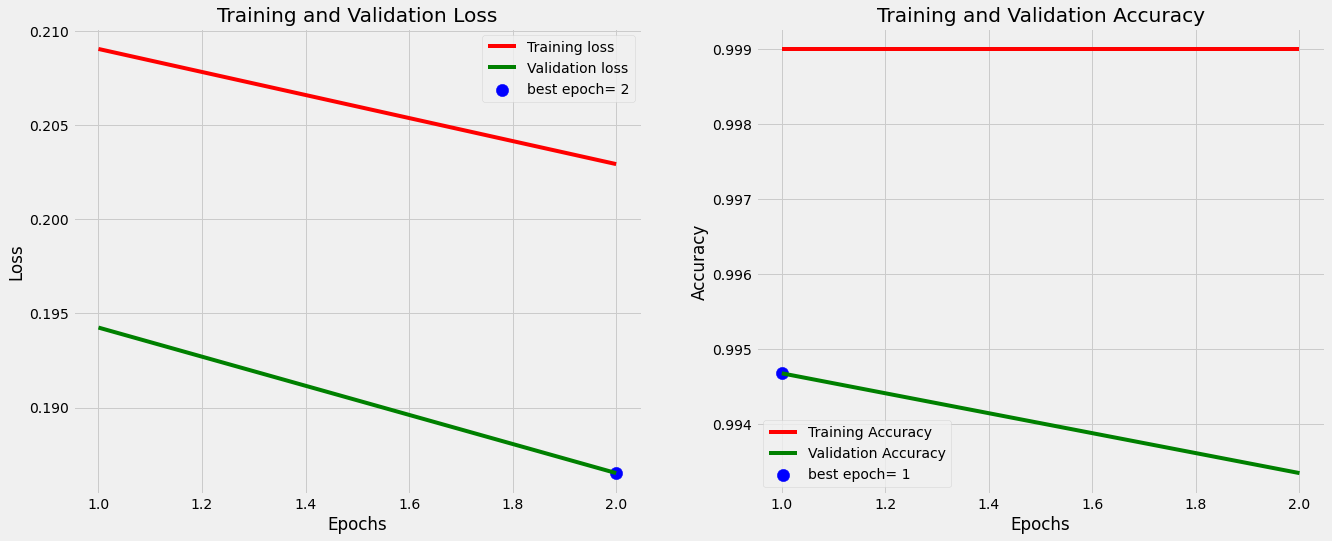

251/251 [==============================] - 6s 24ms/step - loss: 0.2120 - accuracy: 0.9880
accuracy on the test set is 98.80 %



In [25]:
tr_plot(history,0)
save_dir=r'./'
subject='plants'
acc=model.evaluate( test_gen, batch_size=test_batch_size, verbose=1, steps=test_steps, return_dict=False)[1]*100
msg=f'accuracy on the test set is {acc:5.2f} %'
print_in_color(msg, (0,255,0),(55,65,80))
save_id=str (model_name +  '-' + subject +'-'+ str(acc)[:str(acc).rfind('.')+3] + '.h5')
save_loc=os.path.join(save_dir, save_id)
model.save(save_loc)

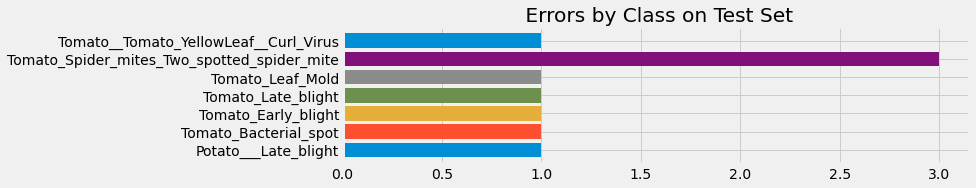

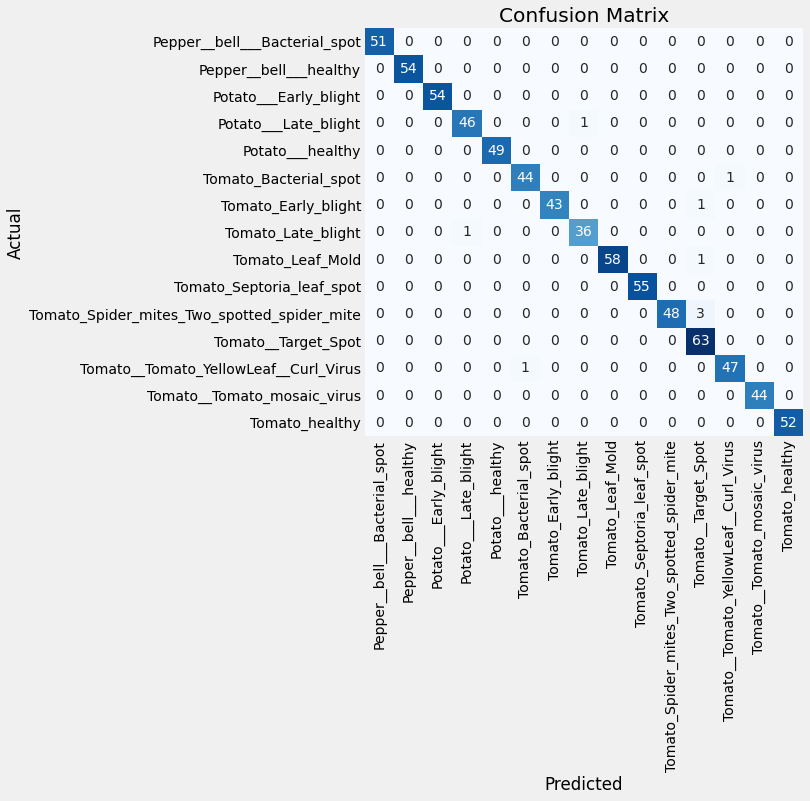

Classification Report:
----------------------
                                              precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00        51
                     Pepper__bell___healthy       1.00      1.00      1.00        54
                      Potato___Early_blight       1.00      1.00      1.00        54
                       Potato___Late_blight       0.98      0.98      0.98        47
                           Potato___healthy       1.00      1.00      1.00        49
                      Tomato_Bacterial_spot       0.98      0.98      0.98        45
                        Tomato_Early_blight       1.00      0.98      0.99        44
                         Tomato_Late_blight       0.97      0.97      0.97        37
                           Tomato_Leaf_Mold       1.00      0.98      0.99        59
                  Tomato_Septoria_leaf_spot       1.00      1.00      1.00        55
Tomato_Spider_mit

In [26]:
print_code=0
preds=model.predict(test_gen) 
print_info( test_gen, preds, print_code, save_dir, subject )  

### some viewers have asked how to use the trained model to predict a single image
### the code below demonstrates that using a Pepper__bell___Bacterial_spot image

Input image shape is  (256, 256, 3)
the resized image has shape  (224, 224, 3)
image shape after expanding dimensions is  (1, 224, 224, 3)
 the shape of prediction is  (1, 15)
the image is predicted as being  Pepper__bell___Bacterial_spot  with a probability of  98.752361536026


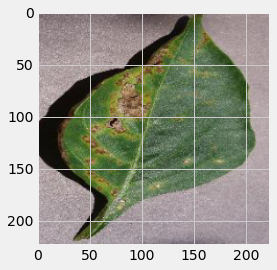

In [27]:
fpath=r'../input/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG'
img=plt.imread(fpath)
print ('Input image shape is ', img.shape)

img=cv2.resize(img, img_size) 
print ('the resized image has shape ', img.shape)
plt.imshow(img)

img=np.expand_dims(img, axis=0)
print ('image shape after expanding dimensions is ',img.shape)
pred=model.predict(img)
print (' the shape of prediction is ', pred.shape)
index=np.argmax(pred[0])
klass=classes[index]
probability=pred[0][index]*100
print('the image is predicted as being ', klass, ' with a probability of ', probability)


In [40]:
import os
import shutil
import zipfile

def create_model_package(model_path, class_dict_path, output_dir='plant_disease_model'):
    """
    Create a complete package for the plant disease classification model
    
    Args:
        model_path: Path to the saved .h5 model file
        class_dict_path: Path to the class dictionary text file
        output_dir: Output directory name for the package
    """
    # Create directory structure
    os.makedirs(os.path.join(output_dir, 'model'), exist_ok=True)
    
    # Copy model files
    shutil.copy(model_path, os.path.join(output_dir, 'model', os.path.basename(model_path)))
    shutil.copy(class_dict_path, os.path.join(output_dir, 'model', os.path.basename(class_dict_path)))
    
    # Create preprocessing.py
    preprocessing_code = '''import cv2
import numpy as np

# Model constants
IMG_SIZE = (224, 224)
IMG_SHAPE = (224, 224, 3)

def preprocess_image(image_path):
    """Preprocess a single image for model prediction"""
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Convert BGR to RGB (OpenCV reads in BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize to model input size
    img = cv2.resize(img, IMG_SIZE)
    
    # No normalization needed for EfficientNet
    # (based on your scalar function that just returns img)
    
    # Add batch dimension
    img = np.expand_dims(img, axis=0)
    
    return img

def load_class_mappings(dict_path):
    """Load class index to name mappings"""
    with open(dict_path, 'r') as f:
        dict_text = f.read()
        # Convert string representation to actual dict
        class_dict = eval(dict_text)
    return class_dict
'''
    
    with open(os.path.join(output_dir, 'preprocessing.py'), 'w') as f:
        f.write(preprocessing_code)
    
    # Create predict.py
    predict_code = '''import os
import numpy as np
import tensorflow as tf
from preprocessing import preprocess_image, load_class_mappings, IMG_SIZE

class PlantDiseaseClassifier:
    def __init__(self, model_path, class_mapping_path):
        # Load model
        self.model = tf.keras.models.load_model(model_path)
        
        # Load class mappings
        self.class_mapping = load_class_mappings(class_mapping_path)
        self.classes = list(self.class_mapping.values())
        
    def predict(self, image_path):
        """Predict plant disease from image"""
        # Preprocess image
        img = preprocess_image(image_path)
        
        # Make prediction
        pred = self.model.predict(img, verbose=0)
        
        # Get predicted class
        index = np.argmax(pred[0])
        class_name = self.classes[index]
        probability = pred[0][index] * 100
        
        return class_name, probability
    
    def predict_batch(self, image_paths):
        """Predict multiple images"""
        results = []
        images = []
        
        # Preprocess all images
        for path in image_paths:
            img = cv2.imread(path)
            if img is None:
                print(f"Warning: Could not read {path}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
        
        if not images:
            return []
        
        # Stack images for batch prediction
        img_array = np.array(images)
        preds = self.model.predict(img_array, verbose=0)
        
        # Process results
        for i, pred in enumerate(preds):
            index = np.argmax(pred)
            class_name = self.classes[index]
            probability = pred[index] * 100
            
            results.append({
                'file': os.path.basename(image_paths[i]),
                'class': class_name,
                'probability': probability
            })
        
        return results

# Example usage
if __name__ == "__main__":
    import cv2
    
    # Initialize classifier
    classifier = PlantDiseaseClassifier(
        model_path='model/''' + os.path.basename(model_path) + '''',
        class_mapping_path='model/''' + os.path.basename(class_dict_path) + ''''
    )
    
    # Example: Single prediction
    print("Single Image Prediction Example:")
    print("--------------------------------")
    # Uncomment and modify the path to test
    # result_class, result_prob = classifier.predict('path/to/test_image.jpg')
    # print(f"Prediction: {result_class} ({result_prob:.2f}%)")
    
    # Example: Batch prediction
    print("\\nBatch Prediction Example:")
    print("-------------------------")
    # Uncomment and modify the paths to test
    # image_files = ['path/to/img1.jpg', 'path/to/img2.jpg']
    # results = classifier.predict_batch(image_files)
    # 
    # print(f"{'FILE':^15s} {'CLASS':^35s} {'PROBABILITY':^15s}")
    # for result in results:
    #     print(f"{result['file']:^15s} {result['class']:^35s} {result['probability']:^15.2f}%")
    
    print("\\nTo use this classifier:")
    print("1. Uncomment the example code above")
    print("2. Replace the image paths with your own")
    print("3. Run the script")
'''
    
    with open(os.path.join(output_dir, 'predict.py'), 'w') as f:
        f.write(predict_code)
    
    # Create requirements.txt
    requirements = '''tensorflow>=2.11.0
numpy>=1.21.6
opencv-python>=4.7.0.72
pillow>=9.4.0
'''
    
    with open(os.path.join(output_dir, 'requirements.txt'), 'w') as f:
        f.write(requirements)
    
    # Create README.md
    readme = '''# Plant Disease Classification Model

This package contains a pre-trained EfficientNetB1 model for classifying plant diseases across 15 categories.

## Installation

1. Create a virtual environment:
   ```bash
   python -m venv venv
   source venv/bin/activate  # On Windows: venv\\Scripts\\activate
   ```

2. Install dependencies:
   ```bash
   pip install -r requirements.txt
   ```

## Quick Start

```python
from predict import PlantDiseaseClassifier

# Initialize classifier
classifier = PlantDiseaseClassifier(
    model_path='model/''' + os.path.basename(model_path) + '''',
    class_mapping_path='model/''' + os.path.basename(class_dict_path) + ''''
)

# Single image prediction
class_name, probability = classifier.predict('path/to/image.jpg')
print(f"Disease: {class_name} ({probability:.2f}%)")

# Batch prediction
results = classifier.predict_batch(['img1.jpg', 'img2.jpg'])
for result in results:
    print(f"{result['file']}: {result['class']} ({result['probability']:.2f}%)")
```

## Model Information

- Architecture: EfficientNetB1
- Input size: 224x224x3
- Number of classes: 15
- Training framework: TensorFlow/Keras

## Preprocessing Details

The model expects:
- RGB images
- Size: 224x224 pixels
- No normalization (EfficientNet handles this internally)
- Images are automatically resized if needed

## Classes

The model can classify the following plant diseases:

**Pepper:**
- Pepper__bell___Bacterial_spot
- Pepper__bell___healthy

**Potato:**
- Potato___Early_blight
- Potato___Late_blight
- Potato___healthy

**Tomato:**
- Tomato__Target_Spot
- Tomato__Tomato_YellowLeaf__Curl_Virus
- Tomato__Tomato_mosaic_virus
- Tomato_Bacterial_spot
- Tomato_Early_blight
- Tomato_Late_blight
- Tomato_Leaf_Mold
- Tomato_Septoria_leaf_spot
- Tomato_Spider_mites_Two_spotted_spider_mite
- Tomato_healthy

## API Reference

### PlantDiseaseClassifier

#### `__init__(model_path, class_mapping_path)`
Initialize the classifier with paths to the model and class mapping files.

#### `predict(image_path)`
Predict the disease class for a single image.

**Returns:** `(class_name, probability)`

#### `predict_batch(image_paths)`
Predict disease classes for multiple images.

**Returns:** List of dictionaries with keys: `file`, `class`, `probability`

## Troubleshooting

1. **ImportError:** Make sure all requirements are installed
2. **FileNotFoundError:** Check that image paths are correct
3. **Memory issues:** For large batches, process images in smaller chunks
4. **GPU support:** Install `tensorflow-gpu` for GPU acceleration

## License

This model is provided for educational and research purposes.
'''
    
    with open(os.path.join(output_dir, 'README.md'), 'w') as f:
        f.write(readme)
    
    # Create a simple test script
    test_script = '''import os
from predict import PlantDiseaseClassifier

def test_model():
    """Simple test to verify the model loads correctly"""
    
    # Initialize classifier
    try:
        classifier = PlantDiseaseClassifier(
            model_path='model/''' + os.path.basename(model_path) + '''',
            class_mapping_path='model/''' + os.path.basename(class_dict_path) + ''''
        )
        print("✓ Model loaded successfully")
    except Exception as e:
        print(f"✗ Model loading failed: {e}")
        return False
    
    # Check if classes are loaded
    if len(classifier.classes) == 15:
        print("✓ All 15 classes loaded")
    else:
        print(f"✗ Expected 15 classes, got {len(classifier.classes)}")
        return False
    
    print("\\nModel classes:")
    for i, cls in enumerate(classifier.classes):
        print(f"{i+1:2d}. {cls}")
    
    print("\\nModel is ready for use!")
    return True

if __name__ == "__main__":
    test_model()
'''
    
    with open(os.path.join(output_dir, 'test_model.py'), 'w') as f:
        f.write(test_script)
    
    # Create __init__.py to make it a package
    with open(os.path.join(output_dir, '__init__.py'), 'w') as f:
        f.write('# Plant Disease Classification Model Package\n')
    
    # Create zip file
    zip_filename = f'{output_dir}.zip'
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(output_dir))
                zipf.write(file_path, arcname)
    
    print(f"Package created successfully: {zip_filename}")
    print(f"Package directory: {output_dir}/")
    print("\nPackage contents:")
    for root, dirs, files in os.walk(output_dir):
        level = root.replace(output_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = ' ' * 4 * (level + 1)
        for file in files:
            print(f"{sub_indent}{file}")
    
    return zip_filename

# Usage example:
if __name__ == "__main__":
    # You need to provide the paths to your saved model and class dictionary
    model_path = "EfficientNetB1-plants-99.47.h5"  # Update with actual path
    class_dict_path = "plants-15.txt"  # Update with actual path
    
    # Create the package
    zip_file = create_model_package(model_path, class_dict_path)
    
    print(f"\nTo use the package:")
    print(f"1. Extract {zip_file}")
    print("2. cd plant_disease_model")
    print("3. pip install -r requirements.txt")
    print("4. python test_model.py")
    print("5. Use predict.py for predictions")

Package created successfully: plant_disease_model.zip
Package directory: plant_disease_model/

Package contents:
plant_disease_model/
    predict.py
    preprocessing.py
    test_model.py
    README.md
    __init__.py
    requirements.txt
    model/
        plants-15.txt
        EfficientNetB1-plants-99.47.h5

To use the package:
1. Extract plant_disease_model.zip
2. cd plant_disease_model
3. pip install -r requirements.txt
4. python test_model.py
5. Use predict.py for predictions


In [43]:
import os
import shutil
import zipfile
import pandas as pd
import numpy as np
from tqdm import tqdm

def create_sample_dataset(df, samples_per_class=5, output_dir='plant_disease_samples', zip_name='plant_disease_samples.zip'):
    """
    Create a sample dataset with a specified number of images from each class
    
    Args:
        df: DataFrame with 'filepaths' and 'labels' columns
        samples_per_class: Number of samples to take from each class
        output_dir: Directory to create the samples in
        zip_name: Name of the output zip file
    """
    
    # Create main output directory
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)
    
    # Group by labels
    groups = df.groupby('labels')
    
    # Create a list to store information about sampled files
    sampled_info = []
    
    print(f"Creating sample dataset with {samples_per_class} samples per class...")
    
    # Process each class
    for label, group in tqdm(groups, desc="Processing classes"):
        # Create directory for this class
        class_dir = os.path.join(output_dir, label)
        os.makedirs(class_dir, exist_ok=True)
        
        # Sample images
        if len(group) > samples_per_class:
            samples = group.sample(n=samples_per_class, random_state=42)
        else:
            samples = group  # Take all if less than requested
        
        # Copy files
        for idx, row in samples.iterrows():
            source_path = row['filepaths']
            if os.path.exists(source_path):
                # Get just the filename
                filename = os.path.basename(source_path)
                
                # Create destination path
                dest_path = os.path.join(class_dir, filename)
                
                # Copy file
                shutil.copy2(source_path, dest_path)
                
                # Store information
                sampled_info.append({
                    'label': label,
                    'original_path': source_path,
                    'sample_path': dest_path,
                    'filename': filename
                })
            else:
                print(f"Warning: File not found: {source_path}")
    
    # Create a CSV with information about the samples
    samples_df = pd.DataFrame(sampled_info)
    samples_df.to_csv(os.path.join(output_dir, 'sample_info.csv'), index=False)
    
    # Create a summary file
    with open(os.path.join(output_dir, 'summary.txt'), 'w') as f:
        f.write("Plant Disease Sample Dataset\n")
        f.write("===========================\n\n")
        f.write(f"Total classes: {len(groups)}\n")
        f.write(f"Samples per class: {samples_per_class}\n")
        f.write(f"Total samples: {len(sampled_info)}\n\n")
        
        f.write("Classes and sample counts:\n")
        f.write("--------------------------\n")
        for label, count in samples_df['label'].value_counts().items():
            f.write(f"{label}: {count} samples\n")
    
    # Create README file
    with open(os.path.join(output_dir, 'README.md'), 'w') as f:
        f.write("# Plant Disease Sample Dataset\n\n")
        f.write("This dataset contains sample images of various plant diseases.\n\n")
        f.write("## Structure\n\n")
        f.write("Each folder is named after a plant disease class and contains sample images.\n\n")
        f.write("## Files\n\n")
        f.write("- `sample_info.csv`: Information about each sample\n")
        f.write("- `summary.txt`: Summary of the dataset\n\n")
        f.write("## Classes\n\n")
        
        for label in sorted(samples_df['label'].unique()):
            f.write(f"- {label}\n")
    
    # Create zip file
    print(f"\nCreating zip file: {zip_name}")
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(output_dir))
                zipf.write(file_path, arcname)
    
    print(f"Sample dataset created successfully!")
    print(f"Output directory: {output_dir}")
    print(f"Zip file: {zip_name}")
    
    return samples_df

# Alternative function if you need to load data from CSV
def load_data_and_create_samples(csv_path='file_paths_labels.csv', samples_per_class=5):
    """
    Load data from CSV and create sample dataset
    
    Args:
        csv_path: Path to CSV file with filepaths and labels
        samples_per_class: Number of samples per class
    """
    # Load data
    df = pd.read_csv(csv_path)
    
    # Create sample dataset
    samples_df = create_sample_dataset(df, samples_per_class)
    
    return samples_df

# Function to create samples from the original PlantVillage structure
def create_samples_from_directory(source_dir='../input/plantdisease/PlantVillage', samples_per_class=5):
    """
    Create sample dataset directly from PlantVillage directory structure
    
    Args:
        source_dir: Source directory with class folders
        samples_per_class: Number of samples per class
    """
    # Create dataframe from directory structure
    filepaths = []
    labels = []
    
    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if os.path.isdir(class_path):
            files = os.listdir(class_path)
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    filepath = os.path.join(class_path, file)
                    filepaths.append(filepath)
                    labels.append(class_name)
    
    # Create dataframe
    df = pd.DataFrame({
        'filepaths': filepaths,
        'labels': labels
    })
    
    # Create sample dataset
    samples_df = create_sample_dataset(df, samples_per_class)
    
    return samples_df

if __name__ == "__main__":
    # Example usage - uncomment the method you want to use
    
    # Method 1: If you have the dataframe already
    # Assuming you have created the dataframe as in your notebook
    """
    import os
    sdir = r'../input/plantdisease/PlantVillage'
    classlist = os.listdir(sdir)    
    filepaths = []
    labels = []    
    for klass in classlist:
        classpath = os.path.join(sdir, klass)
        if os.path.isdir(classpath):
            flist = os.listdir(classpath)        
            for f in flist:
                fpath = os.path.join(classpath, f)        
                filepaths.append(fpath)
                labels.append(klass)
    
    df = pd.DataFrame({
        'filepaths': filepaths,
        'labels': labels
    })
    
    # Create sample dataset
    samples_df = create_sample_dataset(df, samples_per_class=5)
    """
    
    # Method 2: If you have a CSV file
    # samples_df = load_data_and_create_samples('file_paths_labels.csv', samples_per_class=5)
    
    # Method 3: Direct from directory
    samples_df = create_samples_from_directory('../input/plantdisease/PlantVillage', samples_per_class=5)
    


Processing classes:  27%|██▋       | 4/15 [00:00<00:00, 31.48it/s]

Creating sample dataset with 5 samples per class...


Processing classes: 100%|██████████| 15/15 [00:00<00:00, 24.78it/s]



Creating zip file: plant_disease_samples.zip
Sample dataset created successfully!
Output directory: plant_disease_samples
Zip file: plant_disease_samples.zip
Please uncomment one of the methods above to create your sample dataset
